In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, accuracy_score,
                             roc_auc_score, roc_curve, f1_score,
                             matthews_corrcoef,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
 df = pd.read_parquet('C:/Users/Анастасія/Downloads/data_for_ML-tgShifted.parquet')

In [3]:
df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

In [4]:
drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season', 'regions_in_alarm_now',
             'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])

y_cls = df['alarm']
y_reg = df['alarms_last_24h']

print(f"Shape of X: {X.shape}")
print(f"Class balance:\n{y_cls.value_counts(normalize=True).round(3)}")

Shape of X: (808940, 222)
Class balance:
alarm
0    0.789
1    0.211
Name: proportion, dtype: float64


In [5]:
print(y_cls.value_counts(normalize=True).round(3))
print(y_cls.value_counts())

alarm
0    0.789
1    0.211
Name: proportion, dtype: float64
alarm
0    638577
1    170363
Name: count, dtype: int64


In [6]:
# For verifying if the 'regions_in_alarm_now' feature incorrectly includes the current region's status
sample = df[df['alarm'] == 1][['datetime', 'region_id', 'alarm', 'regions_in_alarm_now']].head(10)
print(sample)

# For comparing the average number of regions in alarm to ensure the logic works correctly
print("\nAverage regions_in_alarm_now when alarm=1:", df[df['alarm']==1]['regions_in_alarm_now'].mean())
print("Average regions_in_alarm_now when alarm=0:", df[df['alarm']==0]['regions_in_alarm_now'].mean())

               datetime  region_id  alarm  regions_in_alarm_now
170 2022-02-24 07:00:00         13      1                     1
199 2022-02-24 08:00:00         13      1                     1
211 2022-02-24 09:00:00         13      1                     1
333 2022-02-24 14:00:00         25      1                     1
348 2022-02-24 15:00:00         25      1                     2
351 2022-02-24 15:00:00          2      1                     2
371 2022-02-24 16:00:00          2      1                     2
379 2022-02-24 16:00:00         25      1                     2
406 2022-02-24 17:00:00         25      1                     1
470 2022-02-24 20:00:00         20      1                     1

Average regions_in_alarm_now when alarm=1: 10.273034637802809
Average regions_in_alarm_now when alarm=0: 3.310931962786007


**TimeSeriesSplit**

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()

split_idx = int(len(df) * 0.8)

for lag in [1, 2, 3, 6, 12, 24, 48]:
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(1).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

split_idx = int(len(df) * 0.8)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols_lag = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols_lag].select_dtypes(include=[np.number])
y_cls = df['alarm']
y_reg = df['alarm']

X_train_full = X.iloc[:split_idx]
X_test_final = X.iloc[split_idx:]
y_train_reg  = y_reg.iloc[:split_idx]
y_test_reg   = y_reg.iloc[split_idx:]
y_train_cls  = y_cls.iloc[:split_idx]
y_test_cls   = y_cls.iloc[split_idx:]

print(f"Train: {X_train_full.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test_final.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (646268, 230): 2022-02-26 00:00:00 - 2025-05-15 00:00:00
Test:  (161568, 230): 2025-05-15 00:00:00 - 2026-03-16 23:00:00


**Linear Regression**

In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

scaler_reg = StandardScaler()
X_train_s = scaler_reg.fit_transform(X_train_full)
X_test_s  = scaler_reg.transform(X_test_final)

for alpha in [0.1, 1.0, 10.0, 100.0]:
    scores = cross_val_score(Ridge(alpha=alpha), X_train_s, y_train_reg,
                             cv=3, scoring='r2', n_jobs=-1)
    print(f"  alpha={alpha:6.1f} -  R² CV: {scores.mean():.4f} ± {scores.std():.4f}")

best_alpha = 100.0
lr = Ridge(alpha=best_alpha)
lr.fit(X_train_s, y_train_reg)

y_pred_raw = lr.predict(X_test_s)

y_pred_lr = (y_pred_raw >= 0.5).astype(int)

mse = mean_squared_error(y_test_reg, y_pred_raw)
mae = mean_absolute_error(y_test_reg, y_pred_raw)
r2  = r2_score(y_test_reg, y_pred_raw)

print(f"\nMSE:  {mse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

  alpha=   0.1 -  R² CV: 0.0928 ± 0.0576
  alpha=   1.0 -  R² CV: 0.0931 ± 0.0575
  alpha=  10.0 -  R² CV: 0.0957 ± 0.0562
  alpha= 100.0 -  R² CV: 0.1137 ± 0.0534

MSE:  0.1182
MAE:  0.2552
R²:   0.4233


In [9]:
print(y_train_reg.describe())
print(y_test_reg.describe())

count    646268.000000
mean          0.191628
std           0.393582
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: alarm, dtype: float64
count    161568.000000
mean          0.287557
std           0.452625
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: alarm, dtype: float64


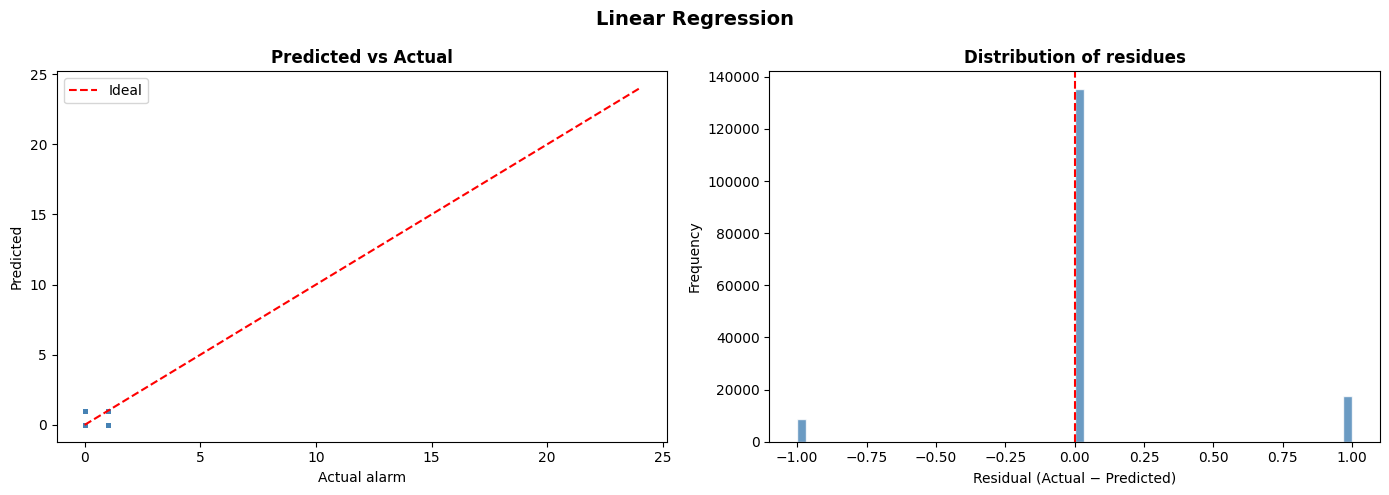

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = np.random.choice(len(y_test_reg), size=5000, replace=False)
axes[0].scatter(y_test_reg.values[sample], y_pred_lr[sample],
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 24], [0, 24], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_xlabel('Actual alarm')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].legend()

residuals = y_test_reg.values - y_pred_lr
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of residues', fontweight='bold')

plt.suptitle('Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Logistic Regression and XGBoost**

In [11]:
for C in [0.01, 0.1, 1.0, 10.0]:
    scores = cross_val_score(
        LogisticRegression(C=C, max_iter=1000, class_weight='balanced'),
        X_train_s, y_train_cls, cv=3, scoring='roc_auc', n_jobs=-1
    )
    print(f"  C={C:6.2f} - ROC-AUC CV: {scores.mean():.4f} ± {scores.std():.4f}")

  C=  0.01 - ROC-AUC CV: 0.6516 ± 0.0592
  C=  0.10 - ROC-AUC CV: 0.6444 ± 0.0514
  C=  1.00 - ROC-AUC CV: 0.6430 ± 0.0501
  C= 10.00 - ROC-AUC CV: 0.6430 ± 0.0501


In [12]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=0.1,
        solver='lbfgs'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_cls==0).sum()/(y_cls==1).sum(),
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

In [13]:
results = {}

for model_name, model in models.items():
    print(f"\n{model_name}")
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_cls.iloc[train_idx], y_train_cls.iloc[val_idx]

        if model_name == 'Logistic Regression':
            sc = StandardScaler()
            X_tr  = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_val)[:, 1]

        fpr, tpr, thresholds = roc_curve(y_val, y_prob)
        optimal_threshold = thresholds[np.argmax(tpr - fpr)]
        y_pred = (y_prob >= optimal_threshold).astype(int)

        fold_metrics.append({
            'fold':    fold + 1,
            'accuracy': accuracy_score(y_val, y_pred),
            'f1':       f1_score(y_val, y_pred, zero_division=0),
            'roc_auc':  roc_auc_score(y_val, y_prob),
            'mcc':      matthews_corrcoef(y_val, y_pred)
        })
        m = fold_metrics[-1]
        print(f"Fold {fold+1}: Acc={m['accuracy']:.3f} | F1={m['f1']:.3f} | ROC-AUC={m['roc_auc']:.3f} | MCC={m['mcc']:.3f}")

    results[model_name] = {'model': model, 'metrics': pd.DataFrame(fold_metrics)}
    avg = pd.DataFrame(fold_metrics).mean(numeric_only=True)
    print(f"\n Avg: Acc={avg['accuracy']:.3f} | F1={avg['f1']:.3f} | ROC-AUC={avg['roc_auc']:.3f} | MCC={avg['mcc']:.3f}")


Logistic Regression
Fold 1: Acc=0.492 | F1=0.252 | ROC-AUC=0.577 | MCC=0.077
Fold 2: Acc=0.583 | F1=0.343 | ROC-AUC=0.679 | MCC=0.197
Fold 3: Acc=0.712 | F1=0.458 | ROC-AUC=0.724 | MCC=0.304
Fold 4: Acc=0.710 | F1=0.512 | ROC-AUC=0.722 | MCC=0.319
Fold 5: Acc=0.763 | F1=0.625 | ROC-AUC=0.841 | MCC=0.479

 Avg: Acc=0.652 | F1=0.438 | ROC-AUC=0.709 | MCC=0.275

XGBoost
Fold 1: Acc=0.665 | F1=0.310 | ROC-AUC=0.662 | MCC=0.175
Fold 2: Acc=0.720 | F1=0.406 | ROC-AUC=0.733 | MCC=0.280
Fold 3: Acc=0.690 | F1=0.475 | ROC-AUC=0.774 | MCC=0.332
Fold 4: Acc=0.737 | F1=0.592 | ROC-AUC=0.817 | MCC=0.431
Fold 5: Acc=0.768 | F1=0.631 | ROC-AUC=0.854 | MCC=0.488

 Avg: Acc=0.716 | F1=0.483 | ROC-AUC=0.768 | MCC=0.341


**Confusion matrices**

In [14]:
final_results = {}

#Linear Regression
scaler_reg = StandardScaler()
X_train_s = scaler_reg.fit_transform(X_train_full)
X_test_s  = scaler_reg.transform(X_test_final)

lr_final = LinearRegression()
lr_final.fit(X_train_s, y_train_reg)
y_prob_lr = lr_final.predict(X_test_s).clip(0, 1)

fpr, tpr, thresholds = roc_curve(y_test_cls, y_prob_lr)
optimal_threshold_lr = thresholds[np.argmax(tpr - fpr)]
y_pred_lr_cls = (y_prob_lr >= optimal_threshold_lr).astype(int)

final_results['Linear Regression'] = {
    'y_pred': y_pred_lr_cls,
    'y_prob': y_prob_lr
}
print(f"Linear Regression — Final Test (threshold={optimal_threshold_lr:.3f}):")
print(classification_report(y_test_cls, y_pred_lr_cls,
                             target_names=['No Alarm', 'Alarm'], zero_division=0))

#Logistic Regression + XGBoost
for model_name, res in results.items():
    model = res['model']

    if model_name == 'Logistic Regression':
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_train_full)
        X_te_s = sc.transform(X_test_final)
        model.fit(X_tr_s, y_train_cls)
        y_prob = model.predict_proba(X_te_s)[:, 1]
    else:
        model.fit(X_train_full, y_train_cls)
        y_prob = model.predict_proba(X_test_final)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test_cls, y_prob)
    optimal_threshold = thresholds[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= optimal_threshold).astype(int)

    final_results[model_name] = {'y_pred': y_pred, 'y_prob': y_prob}

    print(f"\n{model_name} — Final Test (threshold={optimal_threshold:.3f}):")
    print(classification_report(y_test_cls, y_pred,
                                target_names=['No Alarm', 'Alarm'], zero_division=0))

Linear Regression — Final Test (threshold=0.321):
              precision    recall  f1-score   support

    No Alarm       0.91      0.82      0.86    115108
       Alarm       0.64      0.80      0.71     46460

    accuracy                           0.81    161568
   macro avg       0.77      0.81      0.79    161568
weighted avg       0.83      0.81      0.82    161568


Logistic Regression — Final Test (threshold=0.567):
              precision    recall  f1-score   support

    No Alarm       0.91      0.81      0.86    115108
       Alarm       0.63      0.81      0.71     46460

    accuracy                           0.81    161568
   macro avg       0.77      0.81      0.78    161568
weighted avg       0.83      0.81      0.82    161568


XGBoost — Final Test (threshold=0.543):
              precision    recall  f1-score   support

    No Alarm       0.92      0.79      0.85    115108
       Alarm       0.62      0.82      0.70     46460

    accuracy                          

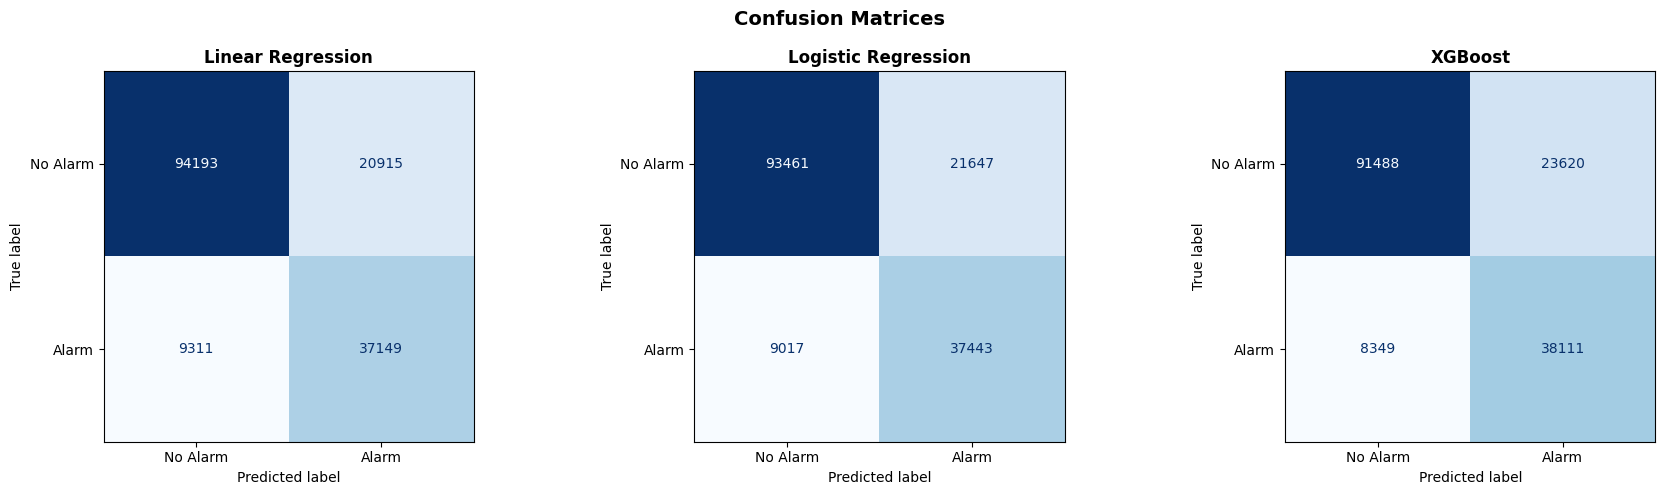

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, res) in zip(axes, final_results.items()):
    cm = confusion_matrix(y_test_cls, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Alarm', 'Alarm'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name}', fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**The top 20 features for each of models**

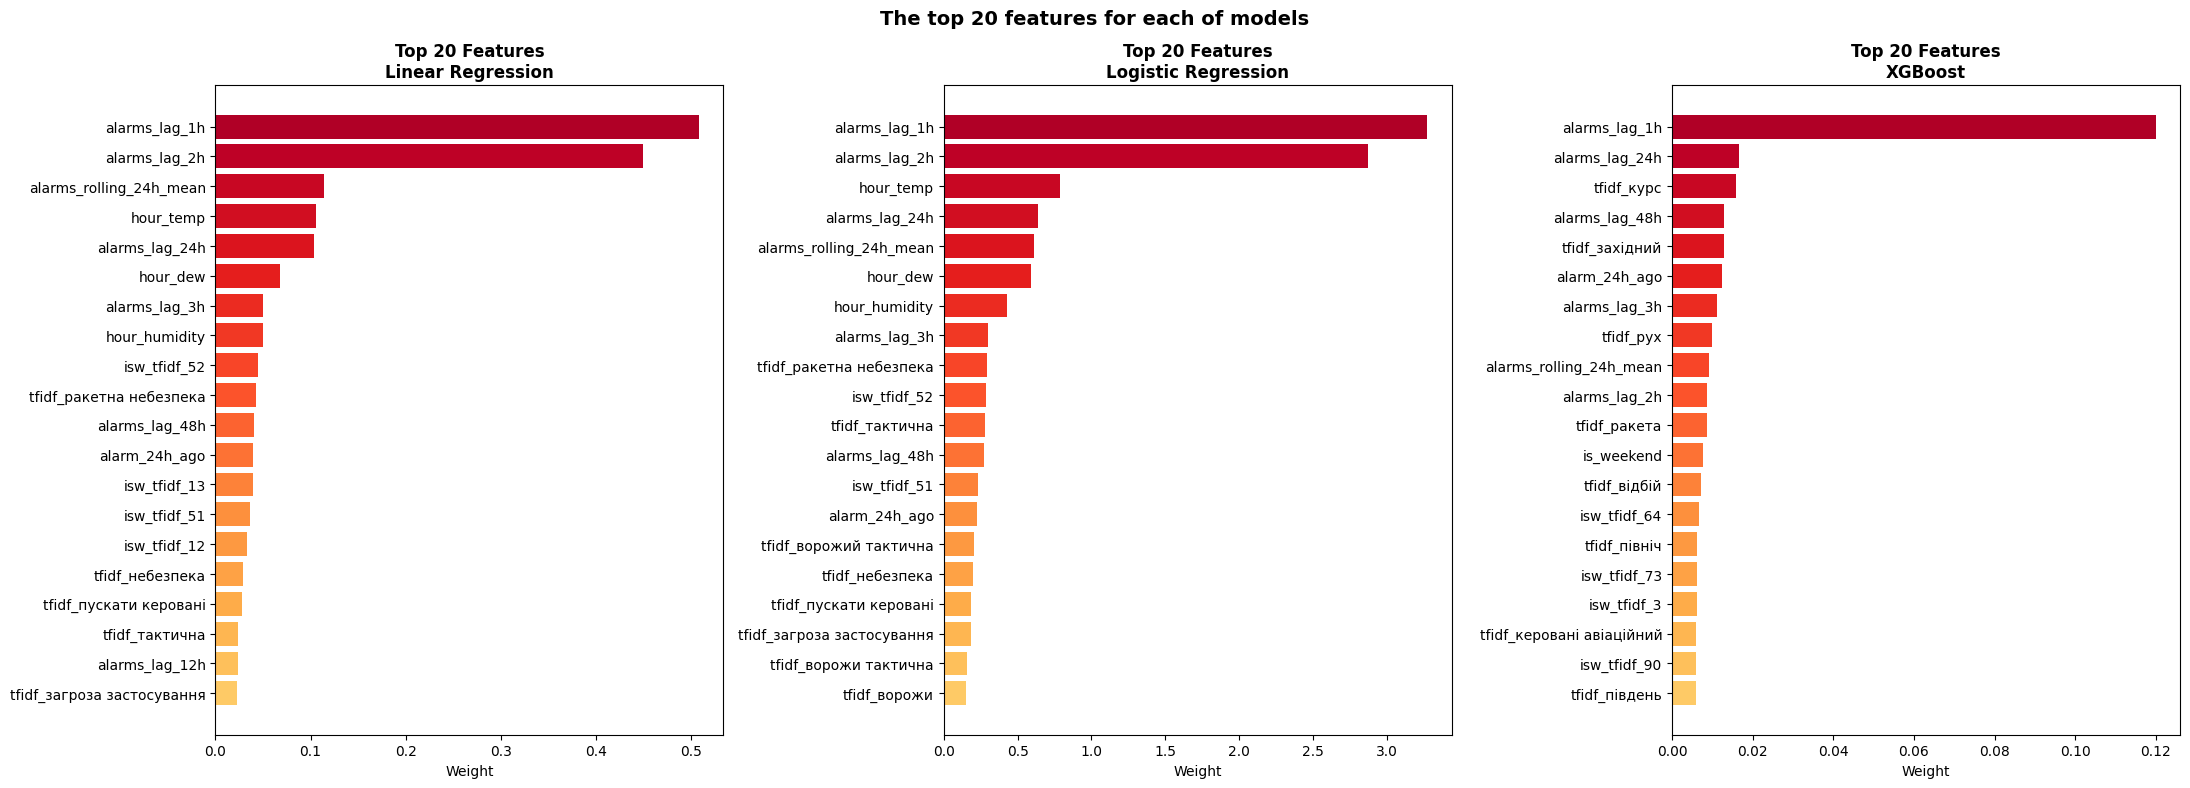

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

models_for_fi = {
    'Linear Regression':    lr_final,
    'Logistic Regression':  results['Logistic Regression']['model'],
    'XGBoost':              results['XGBoost']['model']
}

for ax, (model_name, model) in zip(axes, models_for_fi.items()):
    if model_name == 'Linear Regression':
        importances = np.abs(model.coef_)
    elif model_name == 'Logistic Regression':
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_

    feat_imp = pd.Series(importances, index=X.columns)
    top20 = feat_imp.nlargest(20).sort_values()

    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 20))
    ax.barh(top20.index, top20.values, color=colors)
    ax.set_title(f'Top 20 Features\n{model_name}', fontweight='bold')
    ax.set_xlabel('Weight')

plt.suptitle('The top 20 features for each of models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
summary = []

#Linear Regression
lr_pred = final_results['Linear Regression']['y_pred']
lr_prob = final_results['Linear Regression']['y_prob']
summary.append({
    'Model':   'Linear Regression',
    'Accuracy': f"{accuracy_score(y_test_cls, lr_pred):.3f}",
    'F1':       f"{f1_score(y_test_cls, lr_pred, zero_division=0):.3f}",
    'ROC-AUC': f"{roc_auc_score(y_test_cls, lr_prob):.3f}",
    'MCC':     f"{matthews_corrcoef(y_test_cls, lr_pred):.3f}"
})

#Logistic + XGBoost
for model_name, res in results.items():
    avg = res['metrics'].mean(numeric_only=True)
    summary.append({
        'Model':   model_name,
        'Accuracy': f"{avg['accuracy']:.3f}",
        'F1':       f"{avg['f1']:.3f}",
        'ROC-AUC': f"{avg['roc_auc']:.3f}",
        'MCC':     f"{avg['mcc']:.3f}"
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model Accuracy    F1 ROC-AUC   MCC
  Linear Regression    0.813 0.711   0.884 0.583
Logistic Regression    0.652 0.438   0.709 0.275
            XGBoost    0.716 0.483   0.768 0.341
